# Clustering de riesgo  — K-Means sobre MCA 

Este notebook implementa la clusterización de casos según su perfil de riesgo con **K-Means sobre una reducción de dimensionalidad con MCA**. 

### 1. Carga de librerías

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              calinski_harabasz_score, davies_bouldin_score,
                              adjusted_rand_score)

import prince

### 2. Carga de datos

`data_cluster.csv` trae las variables candidatas de entrada; `data_validacion.csv` trae `numero_de_intentos`, que se usa solo para *validar* los clusters después, nunca para construirlos.

In [40]:
df_cluster = pd.read_csv('data/data_cluster.csv')
df_validacion = pd.read_csv('data/data_validacion.csv')

print(f"Registros: {df_cluster.shape[0]}, columnas originales: {df_cluster.shape[1]}")
df_cluster.head()

Registros: 818, columnas originales: 36


,id_registro,sexo,area_de_residencia,seguridad_social,estrato_socioeconomico,gestante,poblacion_a_cargo_icbf,intentos_previos,estado_civil,conflicto_con_pareja_o_ex_pareja,...,trastorno_bipolar,esquizofrenia,antecedente_violencia_o_abuso,abuso_de_alcohol,remitido_a_psiquiatria,remitido_a_psicologia,remitido_a_trabajo_social,edad_rango,escolaridad_grupo,metodo_principal
0,0,FEMENINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,0,0,1,SOLTERO(A),0,...,0,0,0,0,1,1,0,adulto_joven,Básica,arma_cortopunzante
1,1,FEMENINO,CABECERA MUNICIPAL,CONTRIBUTIVO,5,0,0,0,UNION LIBRE,1,...,0,0,0,0,1,1,0,adulto_mayor,Superior,intoxicaciones
2,2,MASCULINO,CABECERA MUNICIPAL,NO ASEGURADO,2,0,0,1,CASADO(A),1,...,0,0,0,0,1,1,0,adulto_mayor,Superior,lanzamiento_al_vacio
3,3,MASCULINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,0,0,0,SOLTERO(A),1,...,0,0,0,0,1,1,0,joven,Básica,multiple
4,4,MASCULINO,CABECERA MUNICIPAL,CONTRIBUTIVO,3,0,0,1,SOLTERO(A),0,...,0,0,0,0,1,0,0,adulto_joven,Superior,arma_cortopunzante


### 3. Selección final de variables

Se depuran las variables en cinco pasos, con una decisión concreta detrás de cada uno:

1. **Factores binarios raros** (menos del 5% de prevalencia) se eliminan por no aportar separación real; las categorías de `metodo_principal` con 1-3 casos se agrupan en `otro`.
2. **Variables con fuga de información** se excluyen: `remitido_a_*` ya que ocurren después del episodio, y `metodo_principal`, `intentos_previos`, `ideacion_suicida_persistente` y `plan_organizado_de_suicidio` están altamente correlacionadas con `numero_de_intentos` y usarlas como insumo volvería circular la validación.
3. **`sexo`** se excluye para que el clustering agrupe por perfil de riesgo y no por género.
4. **`area_de_residencia`** se excluye por ser casi constante (98.3% de los casos caen en "CABECERA MUNICIPAL"): no separa nada entre casos, y en un primer perfilado aparecía con 94-100% en absolutamente todos los clusters por igual, solo aportaba ruido dimensional para el MCA. Quitarla mejora la silueta (0.247→0.260), Calinski-Harabasz (181.6→217.0), Davies-Bouldin (1.154→1.143) y sobre todo la estabilidad ARI (0.856→0.911), sin sacrificar ningún factor de riesgo relevante.
5. **`estrato_socioeconomico` y `seguridad_social`** también se excluyen del modelo, quitar ambas variables del espacio de clustering sube la silueta de 0.260 a 0.383 y mejora la estabilidad ARI a la vez que la vuelve más consistente (0.911±0.050 → 0.977±0.025). Se conservan aparte para usarlas como **validación/caracterización externa** de cada cluster, igual que `numero_de_intentos` y `remitido_a_psiquiatria`.

Las variables excluidas se conservan aparte para usarlas como validación externa.

In [41]:
factores_raros = ['problemas_juridicos', 'gestante', 'poblacion_a_cargo_icbf',
                   'suicidio_de_un_familiar', 'trastorno_bipolar',
                   'enfermedad_cronica_dolorosa_o_discapacitante', 'muerte_de_un_familiar']
metodos_raros = ['arma_de_fuego', 'inmolacion', 'no especificado']
columnas_leakage = ['remitido_a_psiquiatria', 'remitido_a_psicologia', 'remitido_a_trabajo_social',
                     'metodo_principal', 'intentos_previos', 'ideacion_suicida_persistente',
                     'plan_organizado_de_suicidio']
columnas_no_informativas = ['area_de_residencia']  # 98.3% en una sola categoría, no separa nada
columnas_socioeconomicas = ['estrato_socioeconomico', 'seguridad_social']  # diluyen la señal de riesgo (ver sección 3, paso 5)

df_cluster = df_cluster.drop(columns=factores_raros)
df_cluster['metodo_principal'] = df_cluster['metodo_principal'].replace(
    {metodo: 'otro' for metodo in metodos_raros}
)

df_leakage = df_cluster[['id_registro'] + columnas_leakage].copy()
df_sexo = df_cluster[['id_registro', 'sexo']].copy()
df_no_informativas = df_cluster[['id_registro'] + columnas_no_informativas].copy()
df_socioeconomico = df_cluster[['id_registro'] + columnas_socioeconomicas].copy()
df_cluster = df_cluster.drop(columns=columnas_leakage + ['sexo'] + columnas_no_informativas + columnas_socioeconomicas)

print(f"Variables de entrada al modelo ({df_cluster.shape[1] - 1}): "
      f"{[c for c in df_cluster.columns if c != 'id_registro']}")

Variables de entrada al modelo (17): ['estado_civil', 'conflicto_con_pareja_o_ex_pareja', 'problemas_economicos', 'escolar_educativa', 'maltrato_fisico_sicologico_sexual', 'problemas_laborales', 'problemas_familiares', 'consumo_de_spa', 'antecedentes_familiares_de_conducta_suicida', 'antecedente_trastorno_psicquiatrico', 'trastorno_depresivo', 'trastorno_de_personalidad', 'esquizofrenia', 'antecedente_violencia_o_abuso', 'abuso_de_alcohol', 'edad_rango', 'escolaridad_grupo']


### 4. Variables categóricas y binarias

De las 17 variables de entrada, 3 son categóricas nominales y 14 son binarias (0/1). Ninguna variable ordinal queda ya en el modelo: `estrato_socioeconomico`, la única con orden natural, se excluyó junto con `seguridad_social` (sección 3, paso 5) y se usa más adelante como validación/caracterización externa.

In [42]:
columnas_categoricas = ['estado_civil', 'edad_rango', 'escolaridad_grupo']
binarias = [c for c in df_cluster.columns if c not in ['id_registro'] + columnas_categoricas]

print(f"Categóricas nominales ({len(columnas_categoricas)}): {columnas_categoricas}")
print(f"Binarias ({len(binarias)}): {binarias}")

Categóricas nominales (3): ['estado_civil', 'edad_rango', 'escolaridad_grupo']
Binarias (14): ['conflicto_con_pareja_o_ex_pareja', 'problemas_economicos', 'escolar_educativa', 'maltrato_fisico_sicologico_sexual', 'problemas_laborales', 'problemas_familiares', 'consumo_de_spa', 'antecedentes_familiares_de_conducta_suicida', 'antecedente_trastorno_psicquiatrico', 'trastorno_depresivo', 'trastorno_de_personalidad', 'esquizofrenia', 'antecedente_violencia_o_abuso', 'abuso_de_alcohol']


### 5. Reducción de dimensionalidad con MCA

El dataset de entrada está compuesto enteramente por variables categóricas y binarias (17 de 17), por ello decidimos utilizar **MCA (Análisis de Correspondencias Múltiples)**.

Se ajusta MCA sobre las 17 variables categóricas/binarias. Se realiza el análisis de varianza para determinar el número de componentes.

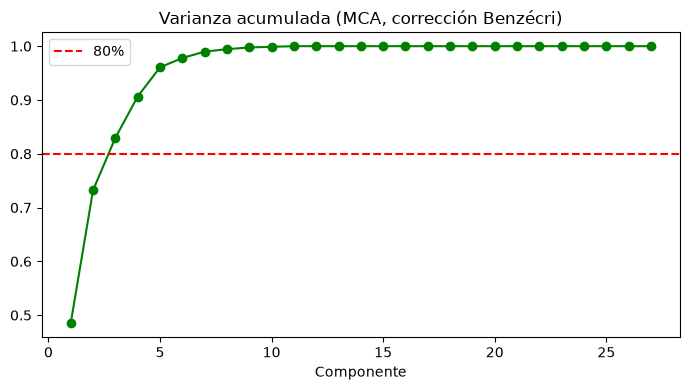

Componentes retenidos para el 80% de varianza: 3 de 27 posibles


In [43]:
mca_input = df_cluster[columnas_categoricas + binarias].astype(str)

n_max = sum(mca_input[c].nunique() for c in mca_input.columns) - mca_input.shape[1]
mca = prince.MCA(n_components=n_max, random_state=42, correction='benzecri').fit(mca_input)

varianza_acumulada = mca.cumulative_percentage_of_variance_ / 100

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', color='green')
plt.axhline(0.80, color='red', linestyle='--', label='80%')
plt.title('Varianza acumulada (MCA, corrección Benzécri)')
plt.xlabel('Componente')
plt.legend()
plt.tight_layout()
plt.show()

n_componentes_80 = int(np.argmax(varianza_acumulada >= 0.80) + 1)
print(f"Componentes retenidos para el 80% de varianza: {n_componentes_80} de {n_max} posibles")

### 6. Espacio final: componentes de MCA

Ahora no queda ninguna variable numérica/ordinal fuera del MCA (`estrato_socioeconomico` se excluyó del modelo en la sección 3). `X_final` es directamente el espacio de componentes de MCA, ya numérico y estandarizado, listo para K-Means. Para graficarlo en 2D más adelante es válido comprimirlo con PCA: `X_final_2d`.

In [44]:
X_mca_raw = mca.row_coordinates(mca_input).to_numpy()[:, :n_componentes_80]
scaler_mca = StandardScaler().fit(X_mca_raw)
X_mca = scaler_mca.transform(X_mca_raw)

X_final = X_mca
X_final_2d = PCA(n_components=2, random_state=42).fit_transform(X_final)

print(f"Espacio final para clustering: {X_final.shape} ({n_componentes_80} ejes MCA)")

Espacio final para clustering: (818, 3) (3 ejes MCA)


### 7. Selección de k: método del codo, silueta y criterios complementarios

Se prueban valores de k entre 2 y 10,  y el tamaño del cluster más pequeño, y el k final se elige explicitando el trade-off entre el criterio estadístico y qué tan accionable es la partición resultante.

,k,inercia,silueta,calinski_harabasz,davies_bouldin,pct_cluster_mas_pequeno
0,2,1728.296,0.330,342.635,1.360,50.000
1,3,1315.565,0.353,352.634,1.115,16.748
2,4,1013.959,0.355,385.352,0.990,14.792
3,5,785.312,0.372,431.881,0.898,14.059
4,6,677.381,0.383,425.939,0.959,7.824
5,7,604.107,0.378,413.907,0.977,6.235
6,8,546.744,0.362,403.656,0.975,6.112
7,9,500.042,0.338,395.155,0.980,5.501
8,10,452.361,0.348,397.255,0.974,3.301


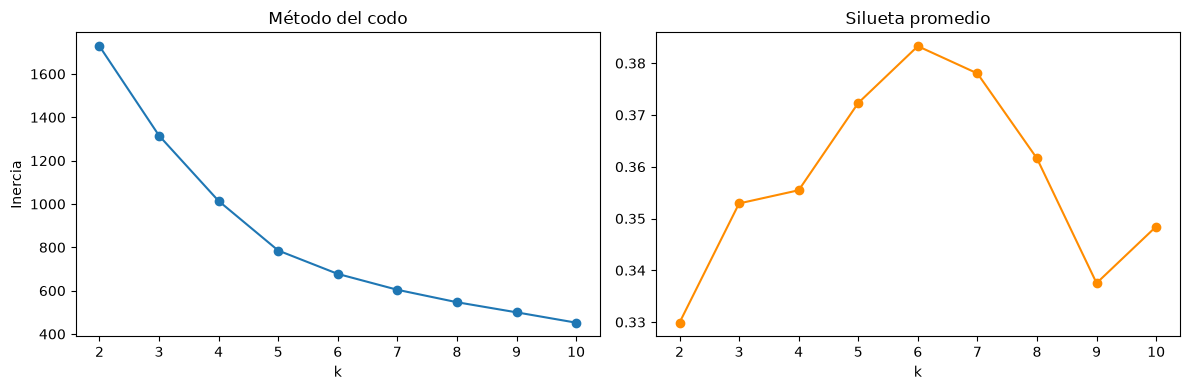


k elegido: 6 (silueta = 0.383) — máxima silueta entre los k con cluster más pequeño ≥ 5% de los casos


In [45]:
rango_k = range(2, 11)
resultados_k = []

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_final)
    etiquetas_k = modelo.labels_
    tamanos = pd.Series(etiquetas_k).value_counts()
    resultados_k.append({
        'k': k,
        'inercia': modelo.inertia_,
        'silueta': silhouette_score(X_final, etiquetas_k),
        'calinski_harabasz': calinski_harabasz_score(X_final, etiquetas_k),
        'davies_bouldin': davies_bouldin_score(X_final, etiquetas_k),
        'pct_cluster_mas_pequeno': tamanos.min() / len(etiquetas_k) * 100,
    })

metricas_k = pd.DataFrame(resultados_k)
display(metricas_k.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metricas_k['k'], metricas_k['inercia'], marker='o')
axes[0].set_title('Método del codo')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercia')

axes[1].plot(metricas_k['k'], metricas_k['silueta'], marker='o', color='darkorange')
axes[1].set_title('Silueta promedio')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

# La silueta sola no basta para decidir k: es prácticamente plana entre k=2 y k=10
# (0.21-0.25, estructura "débil" según Kaufman & Rousseeuw) y su máximo absoluto (k=10)
# deja un cluster de un tamaño poco accionable para un programa de intervención.
# Por eso el k final maximiza la silueta SOLO entre los k cuyo cluster más pequeño
# conserva un tamaño mínimo interpretable.
UMBRAL_TAMANO_MIN = 5  # % mínimo aceptable para el cluster más pequeño

candidatos = metricas_k[metricas_k['pct_cluster_mas_pequeno'] >= UMBRAL_TAMANO_MIN]
k_optimo = int(candidatos.loc[candidatos['silueta'].idxmax(), 'k'])

print(f"\nk elegido: {k_optimo} (silueta = {candidatos['silueta'].max():.3f}) — "
      f"máxima silueta entre los k con cluster más pequeño ≥ {UMBRAL_TAMANO_MIN}% de los casos")

**Selección de k**: tras excluir `estrato_socioeconomico` y `seguridad_social` del espacio de clustering (sección 3, paso 5), la silueta deja de ser plana y se mueve entre 0.330 y 0.383 según k, con **k=6** (silueta=0.383).

### 8. Modelo final: K-Means (k = 6)

Se ajusta el modelo seleccionado sobre `X_final` y se visualiza usando `X_final_2d`, Se marcan los **centroides**  y se acompaña de un **diagrama de silueta**

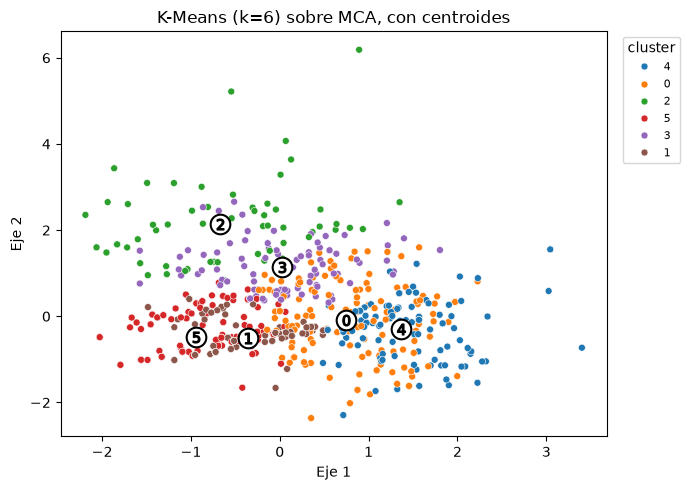

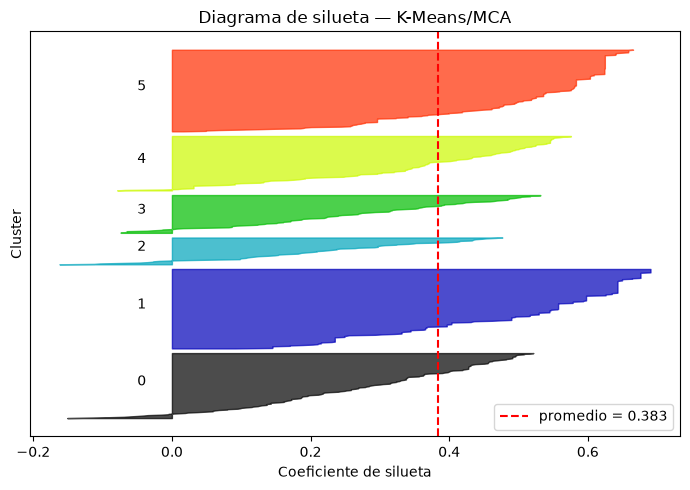

In [46]:
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
etiquetas = kmeans_final.fit_predict(X_final)

# --- Dispersión 2D con centroides ---
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_final_2d[:, 0], y=X_final_2d[:, 1], hue=etiquetas.astype(str),
                 palette='tab10', s=25)

centroides = pd.DataFrame(X_final_2d, columns=['Eje 1', 'Eje 2'])
centroides['cluster'] = etiquetas
centroides = centroides.groupby('cluster')[['Eje 1', 'Eje 2']].mean()
plt.scatter(centroides['Eje 1'], centroides['Eje 2'], marker='o', c='white', s=200,
            edgecolor='black', linewidth=1.5, zorder=5)
for cluster, fila in centroides.iterrows():
    plt.scatter(fila['Eje 1'], fila['Eje 2'], marker=f'${cluster}$', c='black', s=60, zorder=6)

plt.title(f'K-Means (k={k_optimo}) sobre MCA, con centroides')
plt.xlabel('Eje 1')
plt.ylabel('Eje 2')
plt.legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Diagrama de silueta ---
valores_silueta = silhouette_samples(X_final, etiquetas)
promedio_silueta = silhouette_score(X_final, etiquetas)

plt.figure(figsize=(7, 5))
y_lower = 10
for i in range(k_optimo):
    coeffs = np.sort(valores_silueta[etiquetas == i])
    color = plt.cm.nipy_spectral(i / k_optimo)
    plt.fill_betweenx(np.arange(y_lower, y_lower + len(coeffs)), 0, coeffs,
                       facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + len(coeffs) / 2, str(i))
    y_lower += len(coeffs) + 10

plt.axvline(x=promedio_silueta, color='red', linestyle='--', linewidth=1.5,
            label=f'promedio = {promedio_silueta:.3f}')
plt.title('Diagrama de silueta — K-Means/MCA')
plt.xlabel('Coeficiente de silueta')
plt.ylabel('Cluster')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

# calinski_final = calinski_harabasz_score(X_final, etiquetas)
# davies_final = davies_bouldin_score(X_final, etiquetas)
# print(f"Silueta: {promedio_silueta:.3f}  |  Calinski-Harabasz: {calinski_final:.1f}  |  "
#       f"Davies-Bouldin: {davies_final:.3f}")

### 9. Pairplot del espacio final por cluster

Para ver cómo separa el modelo en cada combinación de a pares de los `n_componentes_80` ejes de MCA que realmente usó, se arma un pairplot coloreado por cluster. 

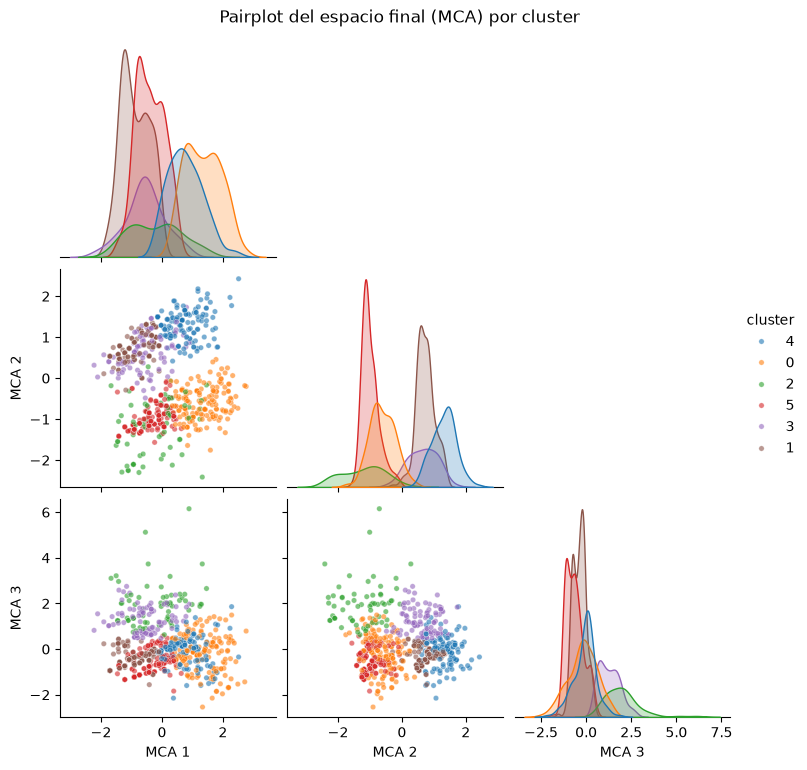

In [47]:
columnas_espacio_final = [f'MCA {i+1}' for i in range(n_componentes_80)]
df_pairplot = pd.DataFrame(X_final, columns=columnas_espacio_final)
df_pairplot['cluster'] = etiquetas.astype(str)

sns.pairplot(df_pairplot, hue='cluster', palette='tab10', corner=True,
             plot_kws={'s': 15, 'alpha': 0.6}, diag_kind='kde')
plt.suptitle('Pairplot del espacio final (MCA) por cluster', y=1.02)
plt.show()

### 10. Estabilidad del modelo

Antes de interpretar los clusters sobre el espacio final, se reajusta el modelo 20 veces sobre el 90% de los datos (muestreado al azar) y se mide qué tan parecidas son esas particiones a la original con el **Adjusted Rand Index (ARI)**

In [48]:
rng = np.random.RandomState(42)
n = X_final.shape[0]
aris = []

for _ in range(20):
    idx_sub = rng.choice(n, size=int(0.9 * n), replace=False)
    modelo_sub = KMeans(n_clusters=k_optimo, random_state=42, n_init=10).fit(X_final[idx_sub])
    etiquetas_pred = modelo_sub.predict(X_final)
    aris.append(adjusted_rand_score(etiquetas, etiquetas_pred))

print(f"ARI promedio sobre 20 reajustes (90% de los datos): {np.mean(aris):.3f} ± {np.std(aris):.3f}")
print("Referencia: ARI > 0.75 = muy estable, 0.4-0.75 = moderada, < 0.4 = poco estable.")

ARI promedio sobre 20 reajustes (90% de los datos): 0.977 ± 0.025
Referencia: ARI > 0.75 = muy estable, 0.4-0.75 = moderada, < 0.4 = poco estable.


### 11. Perfilado de los clusters

Se realiza descripcion de cada cluster en tres partes: un **título resumen** (generado a partir de la edad y el estado civil dominantes más el factor de riesgo más característico), su **perfil demográfico** (la categoría más frecuente en cada variable demográfica, incluida `sexo`, que no se usó como insumo) y sus **factores de riesgo característicos** — los que aparecen notablemente más o menos que el promedio general del dataset, no solo los tres más comunes. También se reportan `numero_de_intentos`, `remitido_a_psiquiatria`, `estrato_socioeconomico` y `seguridad_social` — las cuatro fuera del modelo — como validación/caracterización externa.

In [49]:
demograficas = columnas_categoricas.copy()

perfil = df_cluster[['id_registro'] + demograficas + binarias].copy()
perfil['cluster'] = etiquetas
perfil = perfil.merge(df_validacion[['id_registro', 'numero_de_intentos']], on='id_registro')
perfil = perfil.merge(df_leakage[['id_registro', 'remitido_a_psiquiatria']], on='id_registro')
perfil = perfil.merge(df_sexo, on='id_registro')
perfil = perfil.merge(df_socioeconomico, on='id_registro')

prevalencia_global = perfil[binarias].mean() * 100
UMBRAL = 15  # puntos porcentuales de diferencia frente al promedio general

for cluster_id in sorted(perfil['cluster'].unique()):
    grupo = perfil[perfil['cluster'] == cluster_id]
    n = len(grupo)

    # --- Perfil demográfico: categoría más frecuente de cada variable ---
    rasgos_demo = []
    for var in columnas_categoricas:
        moda = grupo[var].mode().iloc[0]
        pct = (grupo[var] == moda).mean() * 100
        rasgos_demo.append(f"{moda} ({pct:.0f}%)")
    pct_fem = (grupo['sexo'] == 'FEMENINO').mean() * 100
    rasgos_demo.append(f"{pct_fem:.0f}% femenino / {100 - pct_fem:.0f}% masculino")

    # --- Riesgo: factores que más se alejan del promedio general (en cualquier dirección) ---
    prevalencia_cluster = grupo[binarias].mean() * 100
    diferencia = (prevalencia_cluster - prevalencia_global).sort_values(ascending=False)

    altos = diferencia[diferencia > UMBRAL]
    bajos = diferencia[diferencia < -UMBRAL].sort_values()

    texto_altos = ', '.join(f"{f.replace('_', ' ')} ({prevalencia_cluster[f]:.0f}%)" for f in altos.index[:4])
    texto_bajos = ', '.join(f"{f.replace('_', ' ')} ({prevalencia_cluster[f]:.0f}%)" for f in bajos.index[:3])

    # --- Título resumen: edad + estado civil dominantes + rasgo de riesgo más característico ---
    edad_moda = grupo['edad_rango'].mode().iloc[0]
    estado_moda = grupo['estado_civil'].mode().iloc[0].lower()
    if len(altos) > 0:
        rasgo_riesgo = 'con ' + ' y '.join(f.replace('_', ' ') for f in altos.index[:2])
    elif len(bajos) > 0:
        rasgo_riesgo = 'sin ' + bajos.index[0].replace('_', ' ')
    else:
        rasgo_riesgo = 'sin factores de riesgo destacados'
    titulo = f"{edad_moda}, {estado_moda}, {rasgo_riesgo}"

    # --- Validación/caracterización externa: variables fuera del modelo ---
    estrato_moda = grupo['estrato_socioeconomico'].mode().iloc[0]
    seguridad_moda = grupo['seguridad_social'].mode().iloc[0]
    pct_seguridad_moda = (grupo['seguridad_social'] == seguridad_moda).mean() * 100

    print(f"Cluster {cluster_id} — {n} casos ({n / len(perfil) * 100:.1f}%) — \"{titulo}\"")
    print(f"  Demografía: {', '.join(rasgos_demo)}")
    print(f"  Riesgo más frecuente que el promedio: {texto_altos if texto_altos else 'ninguno destacado'}")
    print(f"  Riesgo menos frecuente que el promedio: {texto_bajos if texto_bajos else 'ninguno destacado'}")
    print(f"  numero_de_intentos promedio: {grupo['numero_de_intentos'].mean():.2f}  |  "
          f"remitido a psiquiatría: {grupo['remitido_a_psiquiatria'].mean() * 100:.0f}%")
    print(f"  Estrato socioeconómico (moda): {estrato_moda}  |  "
          f"Seguridad social (moda): {seguridad_moda} ({pct_seguridad_moda:.0f}%)")
    print()

Cluster 0 — 154 casos (18.8%) — "adulto_joven, soltero(a), con conflicto con pareja o ex pareja y abuso de alcohol"
  Demografía: SOLTERO(A) (42%), adulto_joven (36%), Básica (45%), 47% femenino / 53% masculino
  Riesgo más frecuente que el promedio: conflicto con pareja o ex pareja (69%), abuso de alcohol (31%)
  Riesgo menos frecuente que el promedio: antecedente trastorno psicquiatrico (4%), trastorno depresivo (1%), problemas familiares (19%)
  numero_de_intentos promedio: 1.13  |  remitido a psiquiatría: 86%
  Estrato socioeconómico (moda): 3  |  Seguridad social (moda): CONTRIBUTIVO (51%)

Cluster 1 — 188 casos (23.0%) — "joven, soltero(a), con trastorno depresivo y antecedente trastorno psicquiatrico"
  Demografía: SOLTERO(A) (98%), joven (49%), Básica (84%), 74% femenino / 26% masculino
  Riesgo más frecuente que el promedio: trastorno depresivo (97%), antecedente trastorno psicquiatrico (100%)
  Riesgo menos frecuente que el promedio: conflicto con pareja o ex pareja (14%)
  n

### 12. Modelo

Guardamos los artefactos generados

In [50]:
import joblib
from pathlib import Path

ruta_scaler = Path('modelos/scaler')
ruta_clasificacion = Path('modelos/clasificacion')
ruta_scaler.mkdir(parents=True, exist_ok=True)
ruta_clasificacion.mkdir(parents=True, exist_ok=True)

joblib.dump(mca, ruta_scaler / 'mca.pkl')
joblib.dump(scaler_mca, ruta_scaler / 'scaler_mca.pkl')
joblib.dump(kmeans_final, ruta_clasificacion / 'kmeans_final.pkl')

metadata_modelo = {
    'k': k_optimo,
    'n_componentes_mca': n_componentes_80,
    'columnas_categoricas': columnas_categoricas,
    'columnas_binarias': binarias,
    'columnas_validacion_externa': ['numero_de_intentos', 'remitido_a_psiquiatria',
                                     'estrato_socioeconomico', 'seguridad_social'],
    'silueta': float(promedio_silueta),
}
joblib.dump(metadata_modelo, ruta_clasificacion / 'metadata_modelo.pkl')

print("Artefactos guardados:")
for ruta in sorted(ruta_scaler.glob('*.pkl')) + sorted(ruta_clasificacion.glob('*.pkl')):
    print(f" - {ruta}")

Artefactos guardados:
 - modelos\scaler\mca.pkl
 - modelos\scaler\scaler_mca.pkl
 - modelos\clasificacion\kmeans_final.pkl
 - modelos\clasificacion\metadata_modelo.pkl


### 13. Conclusiones

El modelo final (k=6, silueta=0.383, ARI=0.977±0.025 sobre 20 reajustes) produce una segmentación más nítida y más estable que la versión anterior de 19 variables (k=8, silueta=0.260, ARI=0.911±0.050). Excluir `estrato_socioeconomico` y `seguridad_social` del espacio de clustering (sección 3, paso 5) no solo mejoró las métricas: también hizo que los 6 clusters resultantes tengan, cada uno, un título de riesgo distinto entre sí — a diferencia de la versión anterior, donde 2 pares de clusters (1/4/5 y 2/3) compartían esencialmente el mismo eje de riesgo y solo se diferenciaban por estrato o régimen de aseguramiento. `estrato_socioeconomico` y `seguridad_social` no se descartan: se reportan por cluster como **validación/caracterización externa**, igual que `numero_de_intentos` y `remitido_a_psiquiatria`.

**Riesgo clínico más alto (11.0% de los casos)**
- **Cluster 3** (joven, soltero(a), antecedente de trastorno psiquiátrico 99%, trastorno depresivo 92%, antecedente de violencia/abuso 41% y maltrato físico-psicológico-sexual 33%) tiene el promedio de intentos más alto de todos los clusters (1.81) — más alto que el máximo de cualquiera de las dos versiones anteriores del modelo (1.65 y 1.58). Se concentra más en régimen subsidiado (44%) que el resto de clusters de perfil depresivo.

**Comorbilidad psiquiátrica severa (7.8% de los casos)**
- **Cluster 2** (joven, soltero(a), esquizofrenia 47%, trastorno de personalidad 44%, consumo de SPA 45%, antecedente de violencia/abuso 44%) no existía como cluster propio en la versión con 19 variables: esos casos quedaban repartidos entre otros grupos porque estrato/aseguramiento dominaban parte del espacio de clustering. Aquí aparece como el segundo cluster de mayor riesgo (numero_de_intentos = 1.42) y es, junto con el cluster 3, el que más se concentra en régimen subsidiado (59%) y estrato 2.

**Trastorno depresivo / antecedente psiquiátrico, sin comorbilidad severa (38.7% de los casos)**
- **Clusters 1 y 4** comparten el eje trastorno depresivo + antecedente de trastorno psiquiátrico (94-100% de los casos en ambos), pero ahora se diferencian por variables de riesgo reales, no solo demográficas: el cluster 4 (adulto_joven) suma conflicto con pareja o ex pareja (57%) y el cluster 1 (joven) no. numero_de_intentos: 1.27 y 1.22 respectivamente.

**Relacional / consumo, sin antecedente psiquiátrico marcado (18.8% de los casos)**
- **Cluster 0** (adulto_joven, soltero(a), conflicto con pareja o ex pareja 69%, abuso de alcohol 31%, antecedente de trastorno psiquiátrico solo 4%) tiene un perfil situacional, distinto de los clusters 1/3/4 donde predomina la carga clínica. numero_de_intentos = 1.13.

**Menor riesgo relativo (23.6% de los casos)**
- **Cluster 5** (adolescencia, soltero(a), sin antecedente de trastorno psiquiátrico marcado en ningún factor) tiene el promedio de intentos más bajo (0.98) y es el cluster más grande. Según los hallazgos de `02_Analisis_desciptivo.ipynb`, en estas edades los problemas familiares y escolares pesan más que los antecedentes clínicos.

**Validación externa socioeconómica**: los dos clusters de mayor riesgo clínico (2 y 3) son también los que más se inclinan hacia régimen subsidiado y estrato 2, mientras que los demás clusters rondan estrato 3/contributivo sin diferencias marcadas entre sí.

**Limitación persistente**: aunque la silueta mejoró sustancialmente (0.260→0.383), sigue estando por debajo del umbral de "estructura fuerte" (>0.5, según Kaufman & Rousseeuw). 

**Reproducibilidad**: el `MCA`, el `StandardScaler` de los componentes de MCA y el `KMeans` final quedaron persistidos en `modelos/scaler/` y `modelos/clasificacion/`,